# 4 Predictive Analysis

Research question: do Google-search attention factors predict GICS sector returns? This notebook proceeds step by step:

1. Load and align data
2. Exploratory diagnostics
3. In-sample regressions
4. Granger / VAR directional tests
5. OOS forecasting
6. Alpha-style portfolio test


## 1. Load And Align Data

This section pulls monthly sector ETF and SPY returns, aligns them with the Google Trends PCA scores and keyword panel, and constructs both raw sector returns and sector excess returns over SPY. No predictive modeling happens in this section.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


In [2]:
DATA_DIR = Path.cwd()

TRENDS_PATH = DATA_DIR / "trends_final_filtered.csv"
PCA_SCORES_PATH = DATA_DIR / "pca_scores.csv"

START_DATE = "2016-05-01"
END_DATE = "2026-06-01"  # yfinance end is exclusive; this includes May 2026 if available.

SECTOR_TICKERS = {
    "Materials": "XLB",
    "Communication Services": "XLC",
    "Energy": "XLE",
    "Financials": "XLF",
    "Industrials": "XLI",
    "Technology": "XLK",
    "Consumer Staples": "XLP",
    "Real Estate": "XLRE",
    "Utilities": "XLU",
    "Health Care": "XLV",
    "Consumer Discretionary": "XLY",
}

MARKET_TICKER = "SPY"
ALL_TICKERS = list(SECTOR_TICKERS.values()) + [MARKET_TICKER]

PC_COUNTS = [5, 10, 13]
HORIZONS = [1, 2]

print(f"Sector tickers: {SECTOR_TICKERS}")
print(f"Market ticker: {MARKET_TICKER}")


Sector tickers: {'Materials': 'XLB', 'Communication Services': 'XLC', 'Energy': 'XLE', 'Financials': 'XLF', 'Industrials': 'XLI', 'Technology': 'XLK', 'Consumer Staples': 'XLP', 'Real Estate': 'XLRE', 'Utilities': 'XLU', 'Health Care': 'XLV', 'Consumer Discretionary': 'XLY'}
Market ticker: SPY


In [3]:
# Load filtered keyword panel and full-sample PCA scores from the PCA notebook.
# Full-sample PCA scores are useful for diagnostics and in-sample analysis.
# For OOS forecasting later, we will rebuild PCA inside the OOS loop to avoid look-ahead bias.
trends_keywords = pd.read_csv(TRENDS_PATH, index_col=0)
trends_keywords.columns = pd.to_datetime(trends_keywords.columns)
trends_keywords = trends_keywords.apply(pd.to_numeric, errors="coerce").fillna(0)

pca_scores = pd.read_csv(PCA_SCORES_PATH, parse_dates=["date"]).set_index("date").sort_index()
pca_scores.index = pca_scores.index.to_period("M").to_timestamp()

print(f"Filtered keyword panel: {trends_keywords.shape}  (keywords x months)")
print(f"PCA scores: {pca_scores.shape}  (months x PCs)")
print(f"Keyword date range: {trends_keywords.columns.min().date()} to {trends_keywords.columns.max().date()}")
print(f"PCA score date range: {pca_scores.index.min().date()} to {pca_scores.index.max().date()}")
print(f"Stock market anchor present: {'stock market' in trends_keywords.index}")

pca_scores.iloc[:5, :13]


Filtered keyword panel: (163, 121)  (keywords x months)
PCA scores: (121, 121)  (months x PCs)
Keyword date range: 2016-05-01 to 2026-05-01
PCA score date range: 2016-05-01 to 2026-05-01
Stock market anchor present: False


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
date,,,,,,,,,,,,,
2016-05-01,15.270874,7.058147,3.219538,-0.661107,2.313337,-0.854506,2.293406,-0.695372,2.241769,-1.488790,1.794098,-0.356918,0.231584
2016-06-01,1.711560,6.787314,1.805027,-2.083383,3.336154,1.301603,-0.679220,-1.032093,1.956375,0.081326,1.772260,-0.974575,0.600190
2016-07-01,17.449749,7.474903,-0.190481,-4.443894,2.812046,1.433026,-0.902458,-1.816841,2.032350,-0.295101,2.505588,-1.036655,0.489088
2016-08-01,22.880848,7.531968,1.081817,-3.988857,2.021328,1.221206,-1.123180,-2.542899,2.682309,0.900577,1.747872,-1.483248,0.405027
2016-09-01,18.340890,6.591766,4.402958,0.554895,-0.400135,-0.614699,0.615530,-2.719610,2.966655,1.435432,0.085178,0.152876,0.199984


In [4]:
# Download adjusted monthly ETF prices from yfinance.
prices_raw = yf.download(
    ALL_TICKERS,
    start=START_DATE,
    end=END_DATE,
    interval="1mo",
    auto_adjust=True,
    progress=False,
)

if isinstance(prices_raw.columns, pd.MultiIndex):
    if "Close" in prices_raw.columns.get_level_values(0):
        prices = prices_raw["Close"].copy()
    elif "Adj Close" in prices_raw.columns.get_level_values(0):
        prices = prices_raw["Adj Close"].copy()
    else:
        raise ValueError(f"Could not find Close/Adj Close in yfinance columns: {prices_raw.columns}")
else:
    prices = prices_raw.copy()

prices.index = pd.to_datetime(prices.index).tz_localize(None).to_period("M").to_timestamp()
prices = prices.sort_index()
prices = prices.reindex(columns=ALL_TICKERS)

print(f"Downloaded monthly prices: {prices.shape}")
print(f"Price date range: {prices.index.min().date()} to {prices.index.max().date()}")
print("Missing price counts:")
print(prices.isna().sum().sort_values(ascending=False))

prices.head()


Downloaded monthly prices: (121, 12)
Price date range: 2016-05-01 to 2026-05-01
Missing price counts:
Ticker
XLC     25
XLB      0
XLE      0
XLF      0
XLI      0
XLK      0
XLP      0
XLRE     0
XLU      0
XLV      0
XLY      0
SPY      0
dtype: int64


Ticker,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY,SPY
Date,,,,,,,,,,,,
2016-05-01,19.197159,NaN,22.288057,16.003771,46.938000,19.816809,40.299686,22.696083,17.877192,60.375961,35.652065,178.277878
2016-06-01,18.951778,NaN,22.744680,15.404049,47.013527,19.449083,42.205238,23.883507,19.084768,60.680592,35.121143,177.972031
2016-07-01,20.012436,NaN,22.605915,16.021599,48.986069,20.931717,42.112713,24.860672,19.112526,63.889965,36.853218,185.422195
2016-08-01,19.958998,NaN,22.985033,16.638073,49.450272,21.175053,41.866352,23.930136,18.052757,61.816963,36.374588,185.644196
2016-09-01,19.626078,NaN,23.689583,16.094965,49.273041,21.531046,40.965569,23.492826,17.964748,61.264759,36.139797,184.721893


In [5]:
# Convert prices to monthly simple returns.
returns_ticker = prices.pct_change().dropna(how="all")

# Rename sector ETF columns to sector names and keep SPY separately.
ticker_to_sector = {ticker: sector for sector, ticker in SECTOR_TICKERS.items()}
sector_returns = returns_ticker[list(SECTOR_TICKERS.values())].rename(columns=ticker_to_sector)
spy_returns = returns_ticker[[MARKET_TICKER]].rename(columns={MARKET_TICKER: "SPY"})

# Sector excess returns over SPY. This is the main sector-specific target for later tests.
sector_excess_returns = sector_returns.sub(spy_returns["SPY"], axis=0)
sector_excess_returns.columns = [f"{col}_excess" for col in sector_excess_returns.columns]

print(f"Sector returns: {sector_returns.shape}")
print(f"SPY returns: {spy_returns.shape}")
print(f"Sector excess returns: {sector_excess_returns.shape}")
print(f"Return date range: {sector_returns.index.min().date()} to {sector_returns.index.max().date()}")

sector_returns.head()


Sector returns: (120, 11)
SPY returns: (120, 1)
Sector excess returns: (120, 11)
Return date range: 2016-06-01 to 2026-05-01


Ticker,Materials,Communication Services,Energy,Financials,Industrials,Technology,Consumer Staples,Real Estate,Utilities,Health Care,Consumer Discretionary
Date,,,,,,,,,,,
2016-06-01,-0.012782,NaN,0.020487,-0.037474,0.001609,-0.018556,0.047285,0.052318,0.067548,0.005046,-0.014892
2016-07-01,0.055966,NaN,-0.006101,0.040090,0.041957,0.076232,-0.002192,0.040914,0.001454,0.052890,0.049317
2016-08-01,-0.002670,NaN,0.016771,0.038478,0.009476,0.011625,-0.005850,-0.037430,-0.055449,-0.032446,-0.012987
2016-09-01,-0.016680,NaN,0.030653,-0.032642,-0.003584,0.016812,-0.021516,-0.018274,-0.004875,-0.008933,-0.006455
2016-10-01,-0.015896,NaN,-0.022309,0.027687,-0.014685,-0.003429,-0.001560,-0.050549,0.017586,-0.062255,-0.020517


In [6]:
# Align PCA scores and return targets on common monthly dates.
common_idx = pca_scores.index.intersection(sector_returns.index)

pca_scores_aligned = pca_scores.loc[common_idx].copy()
sector_returns_aligned = sector_returns.loc[common_idx].copy()
spy_returns_aligned = spy_returns.loc[common_idx].copy()
sector_excess_aligned = sector_excess_returns.loc[common_idx].copy()

analysis_panel = pd.concat(
    [
        pca_scores_aligned,
        sector_returns_aligned.add_prefix("ret_"),
        sector_excess_aligned.add_prefix("excess_"),
        spy_returns_aligned,
    ],
    axis=1,
)

print(f"Aligned PCA scores: {pca_scores_aligned.shape}")
print(f"Aligned sector returns: {sector_returns_aligned.shape}")
print(f"Aligned sector excess returns: {sector_excess_aligned.shape}")
print(f"Aligned panel: {analysis_panel.shape}")
print(f"Aligned date range: {analysis_panel.index.min().date()} to {analysis_panel.index.max().date()}")
print("\nRemaining missing values by block:")
print({
    "pca_scores": int(pca_scores_aligned.isna().sum().sum()),
    "sector_returns": int(sector_returns_aligned.isna().sum().sum()),
    "sector_excess": int(sector_excess_aligned.isna().sum().sum()),
    "spy_returns": int(spy_returns_aligned.isna().sum().sum()),
})

analysis_panel.head()


Aligned PCA scores: (120, 121)
Aligned sector returns: (120, 11)
Aligned sector excess returns: (120, 11)
Aligned panel: (120, 144)
Aligned date range: 2016-06-01 to 2026-05-01

Remaining missing values by block:
{'pca_scores': 0, 'sector_returns': 25, 'sector_excess': 25, 'spy_returns': 0}


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50,...,PC95,PC96,PC97,PC98,PC99,PC100,PC101,PC102,PC103,PC104,PC105,PC106,PC107,PC108,PC109,PC110,PC111,PC112,PC113,PC114,PC115,PC116,PC117,PC118,PC119,PC120,PC121,ret_Materials,ret_Communication Services,ret_Energy,ret_Financials,ret_Industrials,ret_Technology,ret_Consumer Staples,ret_Real Estate,ret_Utilities,ret_Health Care,ret_Consumer Discretionary,excess_Materials_excess,excess_Communication Services_excess,excess_Energy_excess,excess_Financials_excess,excess_Industrials_excess,excess_Technology_excess,excess_Consumer Staples_excess,excess_Real Estate_excess,excess_Utilities_excess,excess_Health Care_excess,excess_Consumer Discretionary_excess,SPY
2016-06-01,1.711560,6.787314,1.805027,-2.083383,3.336154,1.301603,-0.679220,-1.032093,1.956375,0.081326,1.772260,-0.974575,0.600190,-0.452605,0.072925,-0.053182,0.033223,-0.594290,-0.104572,0.527951,-0.426630,0.732964,0.085809,-0.012558,0.153424,-0.194667,-0.969187,-0.036442,-0.681302,0.444030,0.102942,0.007468,-0.511921,-0.313413,0.074105,-0.923351,0.235129,-0.122177,0.358451,0.155972,0.693045,-0.182914,0.049333,0.004466,0.032280,0.149137,-0.738119,-0.086030,-0.175386,-0.575854,...,0.097862,0.142744,0.065151,0.087257,-0.022176,0.025422,0.051297,-0.022546,-0.066907,-0.009525,-0.009443,0.042483,0.065509,-0.047124,0.066859,0.011216,-0.018382,-0.039247,-0.080547,-0.078783,0.014285,-0.066188,0.010625,0.004990,-0.017741,0.002677,5.095185e-16,-0.012782,NaN,0.020487,-0.037474,0.001609,-0.018556,0.047285,0.052318,0.067548,0.005046,-0.014892,-0.011067,NaN,0.022203,-0.035758,0.003325,-0.016841,0.049000,0.054034,0.069264,0.006761,-0.013176,-0.001716
2016-07-01,17.449749,7.474903,-0.190481,-4.443894,2.812046,1.433026,-0.902458,-1.816841,2.032350,-0.295101,2.505588,-1.036655,0.489088,-0.336672,0.842916,0.139258,-0.675534,-0.147034,1.038489,-0.006911,-0.104616,-0.300584,1.788561,0.007638,-0.038996,0.291213,-0.037167,-0.466192,-0.606942,-0.562215,-0.727933,0.258893,0.141758,-1.092020,-0.866594,-0.896922,-1.062508,0.297697,0.101773,0.355863,0.370775,-0.796075,0.087388,-0.609011,-0.117803,0.235924,0.742069,0.104866,-0.112948,-0.354155,...,-0.043198,-0.022658,-0.046048,-0.050456,-0.012257,0.015694,-0.013328,-0.040144,-0.000634,0.022611,0.020276,0.002178,0.014407,0.053554,-0.007210,0.027749,-0.006755,0.026274,0.045010,0.009961,0.001839,0.041918,-0.019293,-0.014616,-0.017078,-0.014496,2.321708e-15,0.055966,NaN,-0.006101,0.040090,0.041957,0.076232,-0.002192,0.040914,0.001454,0.052890,0.049317,0.014105,NaN,-0.047962,-0.001771,0.000095,0.034370,-0.044054,-0.000948,-0.040407,0.011028,0.007456,0.041861
2016-08-01,22.880848,7.531968,1.081817,-3.988857,2.021328,1.221206,-1.123180,-2.542899,2.682309,0.900577,1.747872,-1.483248,0.405027,-0.532165,0.504302,0.690885,-1.543804,0.906044,1.057782,0.463198,-1.119226,-0.079315,0.006739,0.999356,-1.005578,-0.091509,-1.036824,0.961068,0.775481,-0.713689,-0.632901,-0.704147,0.428355,1.196124,0.098024,-0.007304,0.743280,0.270566,-0.803057,-0.608978,-0.073612,-0.258511,0.033355,0.346989,0.665776,-0.109933,-0.686195,0.032490,-0.111236,0.118368,...,0.071798,-0.007300,0.091540,-0.054860,0.041854,-0.005752,-0.035629,0.023046,-0.002381,0.033730,0.040442,-0.017147,-0.063487,-0.006417,0.023877,-0.004935,0.007798,-0.026351,-0.001568,0.010075,0.024094,0.016597,0.002801,0.000371,0.023307,0.012694,2.127515e-15,-0.002670,NaN,0.016771,0.038478,0.009476,0.011625,-0.005850,-0.037430,-0.055449,-0.032446,-0.012987,-0.003868,NaN,0.015573,0.037280,0.008279,0.010428,-0.007047,-0.038627,-0.056646,-0.033644,-0.014185,0.001197
2016-09-01,18.340890,6.591766,4.402958,0.554895,-0.400135,-0.614699,0.615530,-2.719610,2.966655,1.435432,0.085178,0.152876,0.199984,0.379634,-0.478884,0.389136,-0.516588,0.580033,1.113390,-0.176628,-1.369471,-0.347962,-1.371965,-0.05

In [7]:
# Save aligned data for later sections.
pca_scores_aligned.to_csv(DATA_DIR / "aligned_pca_scores.csv")
sector_returns_aligned.to_csv(DATA_DIR / "aligned_sector_returns.csv")
sector_excess_aligned.to_csv(DATA_DIR / "aligned_sector_excess_returns.csv")
spy_returns_aligned.to_csv(DATA_DIR / "aligned_spy_returns.csv")
analysis_panel.to_csv(DATA_DIR / "analysis_panel.csv")

print("Saved aligned data files:")
print("  aligned_pca_scores.csv")
print("  aligned_sector_returns.csv")
print("  aligned_sector_excess_returns.csv")
print("  aligned_spy_returns.csv")
print("  analysis_panel.csv")


Saved aligned data files:
  aligned_pca_scores.csv
  aligned_sector_returns.csv
  aligned_sector_excess_returns.csv
  aligned_spy_returns.csv
  analysis_panel.csv


## 2. Exploratory Diagnostics

Quick visual and statistical checks before modeling. These diagnostics focus on whether the return data, PC scores, and sector relationships look sensible after alignment.


In [8]:
import matplotlib.pyplot as plt

SECTOR_NAMES = list(SECTOR_TICKERS.keys())
PC_DIAGNOSTIC_COUNT = 13
PC_DIAGNOSTIC_COLS = [f"PC{i}" for i in range(1, PC_DIAGNOSTIC_COUNT + 1)]

# Keep Communication Services separate in diagnostics when full-sample missing values matter.
sector_missing = sector_returns_aligned.isna().sum().sort_values(ascending=False)
full_sample_sectors = sector_missing[sector_missing == 0].index.tolist()

print("Missing monthly return observations by sector:")
print(sector_missing)
print(f"\nSectors with complete return history: {len(full_sample_sectors)}")
print(full_sample_sectors)


Missing monthly return observations by sector:
Ticker
Communication Services    25
Materials                  0
Energy                     0
Financials                 0
Industrials                0
Technology                 0
Consumer Staples           0
Real Estate                0
Utilities                  0
Health Care                0
Consumer Discretionary     0
dtype: int64

Sectors with complete return history: 10
['Materials', 'Energy', 'Financials', 'Industrials', 'Technology', 'Consumer Staples', 'Real Estate', 'Utilities', 'Health Care', 'Consumer Discretionary']


In [9]:
# Sector return summary statistics
summary_stats = pd.DataFrame({
    "mean_monthly": sector_returns_aligned.mean(),
    "vol_monthly": sector_returns_aligned.std(),
    "ann_return_approx": sector_returns_aligned.mean() * 12,
    "ann_vol": sector_returns_aligned.std() * np.sqrt(12),
    "ann_sharpe_approx": (sector_returns_aligned.mean() / sector_returns_aligned.std()) * np.sqrt(12),
    "min_monthly": sector_returns_aligned.min(),
    "max_monthly": sector_returns_aligned.max(),
    "missing": sector_returns_aligned.isna().sum(),
}).round(4)

summary_stats.sort_values("ann_sharpe_approx", ascending=False)


,mean_monthly,vol_monthly,ann_return_approx,ann_vol,ann_sharpe_approx,min_monthly,max_monthly,missing
Ticker,,,,,,,,
Technology,0.0203,0.0591,0.2434,0.2046,1.1894,-0.1218,0.2016,0
Industrials,0.0124,0.0553,0.1487,0.1915,0.7767,-0.1925,0.1603,0
Communication Services,0.0113,0.0552,0.1352,0.1913,0.7066,-0.1391,0.1506,25
Financials,0.0115,0.0572,0.1380,0.1981,0.6966,-0.2170,0.1685,0
Health Care,0.0085,0.0422,0.1018,0.1463,0.6959,-0.0976,0.1313,0
Consumer Discretionary,0.0118,0.0592,0.1419,0.2051,0.6918,-0.1532,0.1946,0
Utilities,0.0088,0.0457,0.1060,0.1584,0.6689,-0.1188,0.1036,0
Consumer Staples,0.0070,0.0391,0.0837,0.1354,0.6183,-0.0974,0.0972,0
Materials,0.0095,0.0546,0.1145,0.1890,0.6056,-0.1457,0.1596,0


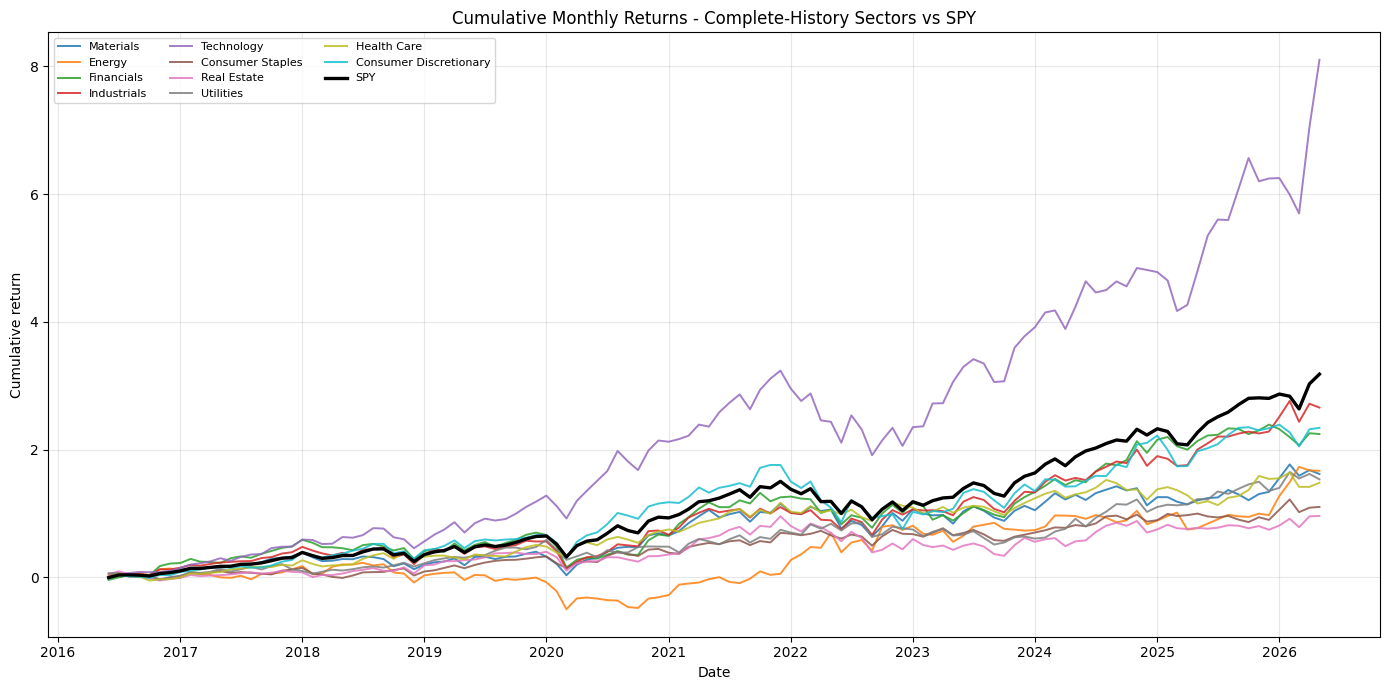

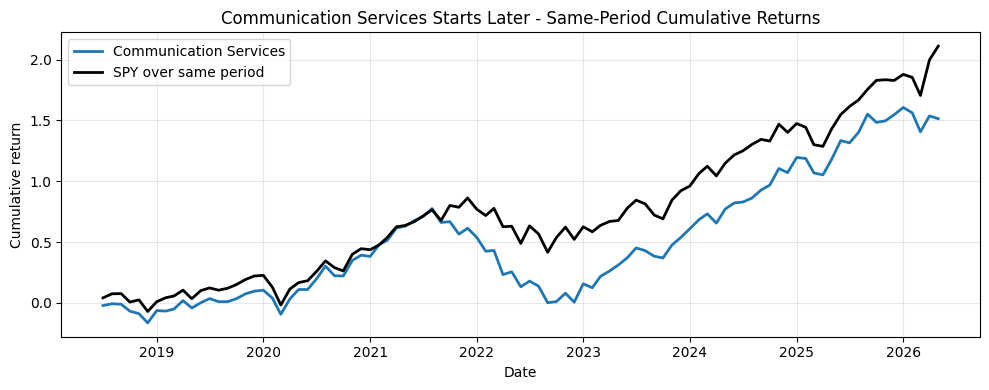

In [10]:
# Cumulative sector and SPY returns
cum_sector = (1 + sector_returns_aligned[full_sample_sectors]).cumprod() - 1
cum_spy = (1 + spy_returns_aligned["SPY"]).cumprod() - 1

fig, ax = plt.subplots(figsize=(14, 7))
for sector in full_sample_sectors:
    ax.plot(cum_sector.index, cum_sector[sector], linewidth=1.4, alpha=0.85, label=sector)
ax.plot(cum_spy.index, cum_spy, color="black", linewidth=2.4, label="SPY")
ax.set_title("Cumulative Monthly Returns - Complete-History Sectors vs SPY")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

# Communication Services starts later because XLC history is shorter.
if sector_returns_aligned["Communication Services"].notna().any():
    xlc_returns = sector_returns_aligned["Communication Services"].dropna()
    xlc_cum = (1 + xlc_returns).cumprod() - 1
    spy_same = (1 + spy_returns_aligned.loc[xlc_returns.index, "SPY"]).cumprod() - 1

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(xlc_cum.index, xlc_cum, label="Communication Services", linewidth=2)
    ax.plot(spy_same.index, spy_same, label="SPY over same period", color="black", linewidth=2)
    ax.set_title("Communication Services Starts Later - Same-Period Cumulative Returns")
    ax.set_ylabel("Cumulative return")
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


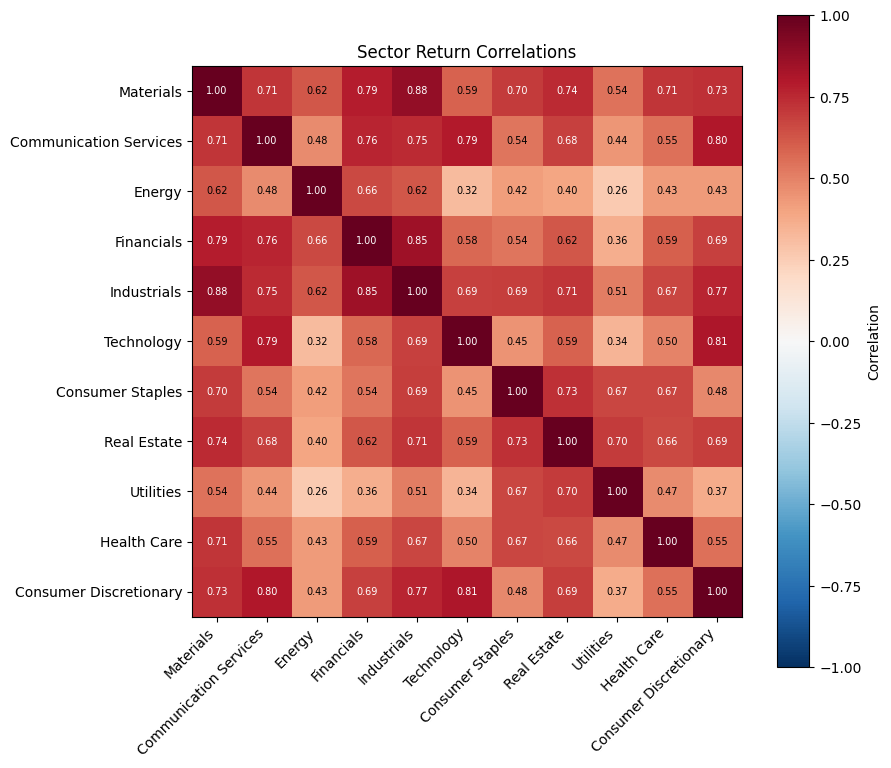

In [11]:
# Sector return correlation heatmap
sector_corr = sector_returns_aligned.corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(sector_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(sector_corr.columns)))
ax.set_yticks(range(len(sector_corr.index)))
ax.set_xticklabels(sector_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(sector_corr.index)
ax.set_title("Sector Return Correlations")

for i in range(len(sector_corr.index)):
    for j in range(len(sector_corr.columns)):
        val = sector_corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(val) > 0.65 else "black")

plt.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()


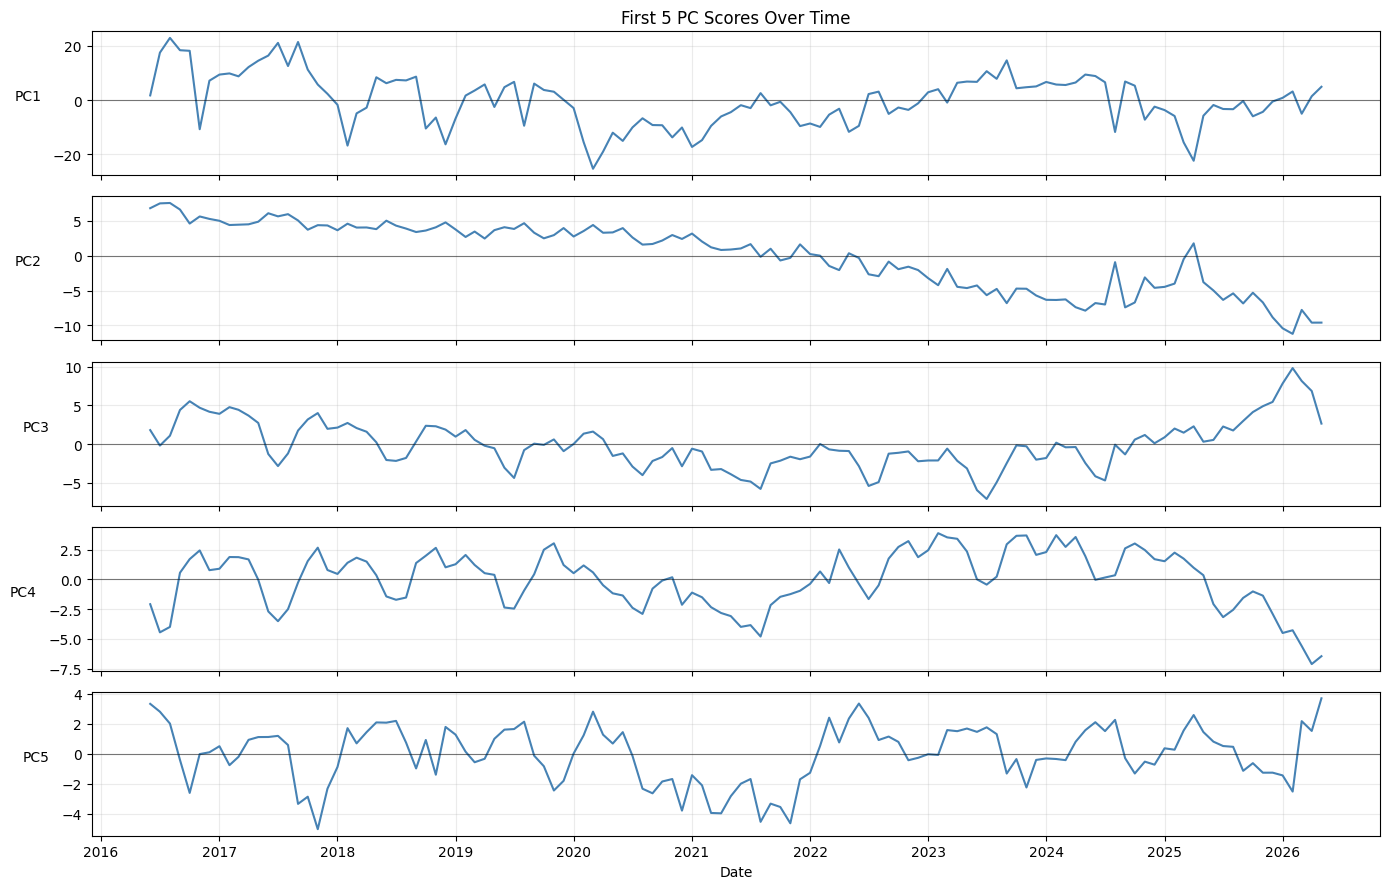

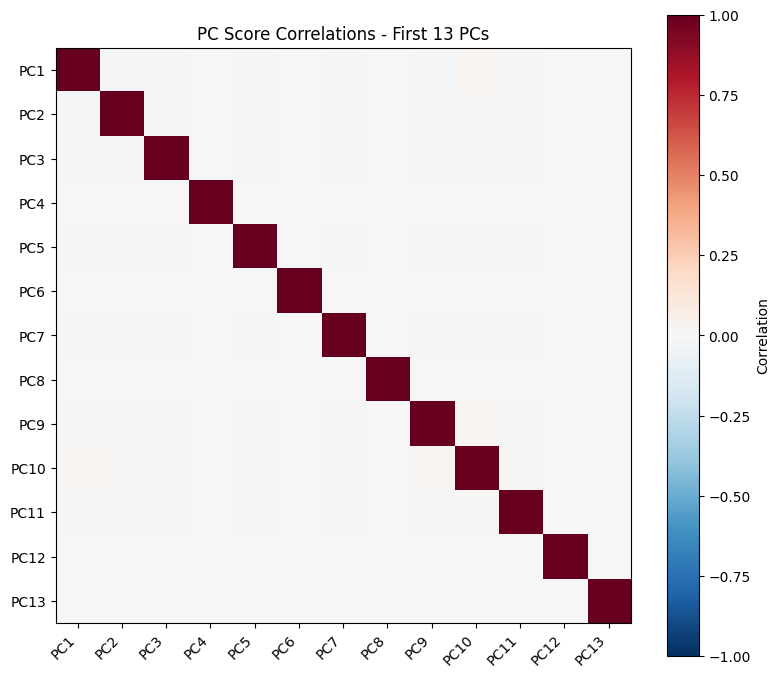

In [12]:
# First 13 PC score behavior
pc_subset = pca_scores_aligned[PC_DIAGNOSTIC_COLS]

fig, axes = plt.subplots(5, 1, figsize=(14, 9), sharex=True)
for ax, pc in zip(axes, PC_DIAGNOSTIC_COLS[:5]):
    ax.plot(pc_subset.index, pc_subset[pc], linewidth=1.5, color="steelblue")
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_ylabel(pc, rotation=0, labelpad=18)
    ax.grid(True, alpha=0.25)
axes[0].set_title("First 5 PC Scores Over Time")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

pc_corr = pc_subset.corr()
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(pc_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(pc_corr.columns)))
ax.set_yticks(range(len(pc_corr.index)))
ax.set_xticklabels(pc_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(pc_corr.index)
ax.set_title("PC Score Correlations - First 13 PCs")
plt.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()


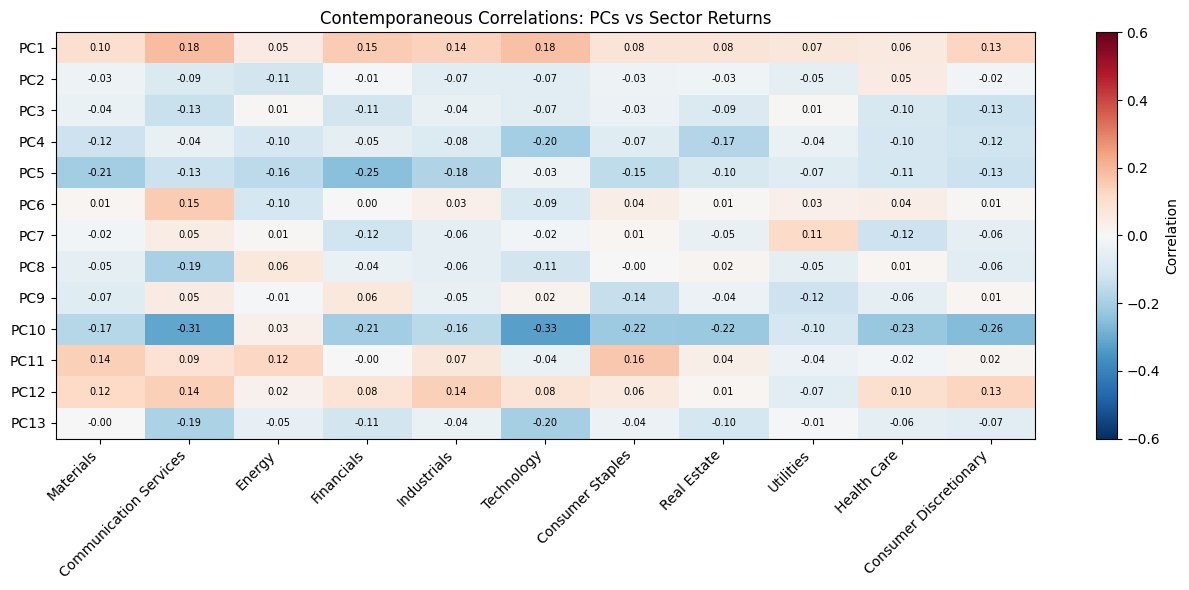

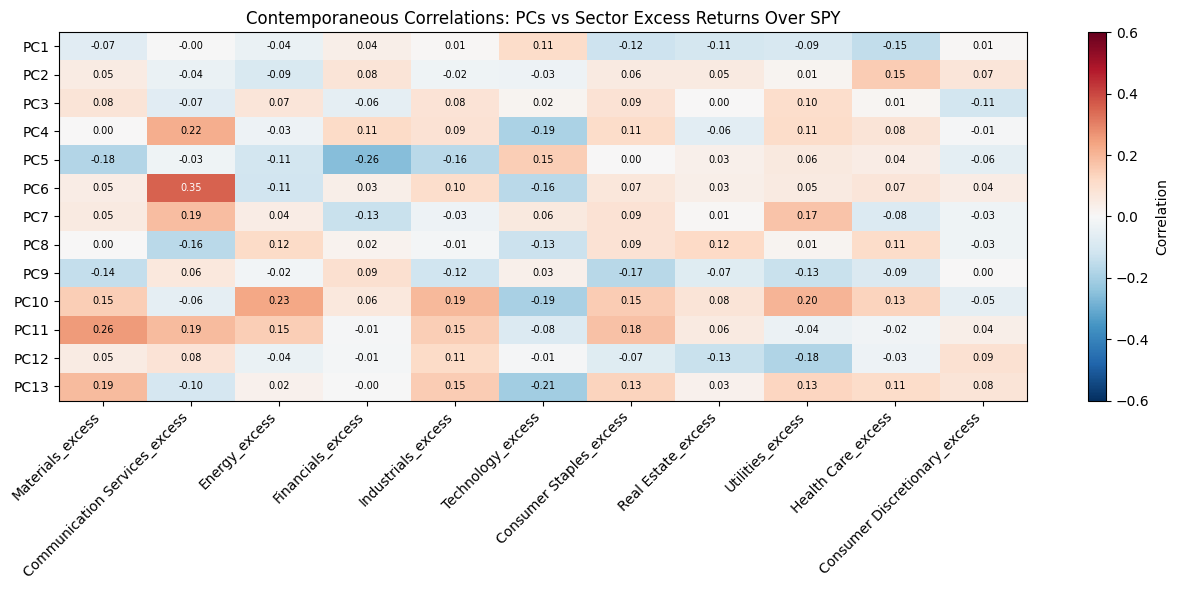

In [13]:
# Contemporaneous correlations between PCs and sector returns.
# These are diagnostics only, not predictive evidence.
def plot_pc_return_corr(return_df, title):
    corr = pd.DataFrame(index=PC_DIAGNOSTIC_COLS, columns=return_df.columns, dtype=float)
    for pc in PC_DIAGNOSTIC_COLS:
        for sector in return_df.columns:
            joined = pd.concat([pca_scores_aligned[pc], return_df[sector]], axis=1).dropna()
            corr.loc[pc, sector] = joined.iloc[:, 0].corr(joined.iloc[:, 1])

    fig, ax = plt.subplots(figsize=(13, 6))
    im = ax.imshow(corr.astype(float), cmap="RdBu_r", vmin=-0.6, vmax=0.6, aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.index)
    ax.set_title(title)

    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            val = corr.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if abs(val) > 0.35 else "black")

    plt.colorbar(im, ax=ax, label="Correlation")
    plt.tight_layout()
    plt.show()
    return corr

pc_sector_corr = plot_pc_return_corr(
    sector_returns_aligned,
    "Contemporaneous Correlations: PCs vs Sector Returns",
)

pc_excess_corr = plot_pc_return_corr(
    sector_excess_aligned,
    "Contemporaneous Correlations: PCs vs Sector Excess Returns Over SPY",
)


In [14]:
# Largest absolute contemporaneous PC/return correlations for quick inspection.
def top_abs_corr(corr_df, n=15):
    out = (
        corr_df.stack()
        .rename("corr")
        .reset_index()
        .rename(columns={"level_0": "PC", "level_1": "target"})
    )
    out["abs_corr"] = out["corr"].abs()
    return out.sort_values("abs_corr", ascending=False).head(n).drop(columns="abs_corr")

print("Top absolute PC/raw-sector correlations:")
display(top_abs_corr(pc_sector_corr, 15))

print("Top absolute PC/sector-excess correlations:")
display(top_abs_corr(pc_excess_corr, 15))


Top absolute PC/raw-sector correlations:


,PC,Ticker,corr
104,PC10,Technology,-0.326694
100,PC10,Communication Services,-0.312179
109,PC10,Consumer Discretionary,-0.260059
47,PC5,Financials,-0.250530
108,PC10,Health Care,-0.225012
106,PC10,Real Estate,-0.224678
105,PC10,Consumer Staples,-0.219519
44,PC5,Materials,-0.209100
102,PC10,Financials,-0.207255
38,PC4,Technology,-0.203122


Top absolute PC/sector-excess correlations:


,PC,target,corr
56,PC6,Communication Services_excess,0.353813
47,PC5,Financials_excess,-0.256884
110,PC11,Materials_excess,0.255175
101,PC10,Energy_excess,0.230521
34,PC4,Communication Services_excess,0.215800
137,PC13,Technology_excess,-0.209470
107,PC10,Utilities_excess,0.204604
104,PC10,Technology_excess,-0.193488
103,PC10,Industrials_excess,0.192680
111,PC11,Communication Services_excess,0.191671


## 3. Granger / VAR Directional Tests

These tests ask whether lagged attention factors improve forecasts of sector returns beyond lagged sector returns. This is Granger-style predictive causality, not true economic causality. We also run the reverse direction to see whether sector returns appear to lead the attention factors.


In [15]:
from scipy import stats

# Granger-style joint F-test implemented directly with OLS.
# Restricted model: y_t ~ const + lags(y)
# Unrestricted model: y_t ~ const + lags(y) + lags(X block)
def _lagged_columns(values, lags, prefix):
    cols = []
    names = []
    for lag in range(1, lags + 1):
        cols.append(values.shift(lag))
        names.extend([f"{prefix}_lag{lag}_{col}" for col in values.columns])
    out = pd.concat(cols, axis=1)
    out.columns = names
    return out


def _ols_rss(y, X):
    X_arr = np.asarray(X, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    beta, *_ = np.linalg.lstsq(X_arr, y_arr, rcond=None)
    resid = y_arr - X_arr @ beta
    return float(resid @ resid), len(y_arr), X_arr.shape[1]


def granger_block_test(y, x_block, lags=1):
    y = y.rename("y").astype(float)
    x_block = x_block.astype(float)

    y_lags = _lagged_columns(y.to_frame(), lags, "y")
    x_lags = _lagged_columns(x_block, lags, "x")

    data = pd.concat([y, y_lags, x_lags], axis=1).dropna()
    if data.empty:
        return {"F": np.nan, "pvalue": np.nan, "nobs": 0, "df_num": np.nan, "df_den": np.nan}

    y_dep = data["y"]
    X_restricted = pd.concat([
        pd.Series(1.0, index=data.index, name="const"),
        data[y_lags.columns],
    ], axis=1)
    X_unrestricted = pd.concat([X_restricted, data[x_lags.columns]], axis=1)

    rss_r, nobs, k_r = _ols_rss(y_dep, X_restricted)
    rss_u, _, k_u = _ols_rss(y_dep, X_unrestricted)

    q = k_u - k_r
    df_den = nobs - k_u
    if q <= 0 or df_den <= 0 or rss_u <= 0:
        return {"F": np.nan, "pvalue": np.nan, "nobs": nobs, "df_num": q, "df_den": df_den}

    F = ((rss_r - rss_u) / q) / (rss_u / df_den)
    pvalue = stats.f.sf(F, q, df_den)
    return {"F": F, "pvalue": pvalue, "nobs": nobs, "df_num": q, "df_den": df_den}


In [16]:
# Run PC -> sector-return Granger-style tests.
GRANGER_PC_COUNTS = [5, 10, 13]
GRANGER_LAGS = [1, 2]

def run_pc_to_targets(target_df, target_type):
    rows = []
    for pc_count in GRANGER_PC_COUNTS:
        pc_cols = [f"PC{i}" for i in range(1, pc_count + 1)]
        x_block = pca_scores_aligned[pc_cols]
        for lags in GRANGER_LAGS:
            for target in target_df.columns:
                y = target_df[target]
                result = granger_block_test(y, x_block, lags=lags)
                rows.append({
                    "direction": "PCs -> target",
                    "target_type": target_type,
                    "target": target,
                    "pc_count": pc_count,
                    "lags": lags,
                    **result,
                })
    return pd.DataFrame(rows)

raw_granger = run_pc_to_targets(sector_returns_aligned, "raw_sector_return")
excess_granger = run_pc_to_targets(sector_excess_aligned, "sector_excess_return")
pc_to_sector_granger = pd.concat([raw_granger, excess_granger], ignore_index=True)

print("Smallest p-values for PC -> sector/sector-excess tests:")
pc_to_sector_granger.sort_values("pvalue").head(20)


Smallest p-values for PC -> sector/sector-excess tests:


,direction,target_type,target,pc_count,lags,F,pvalue,nobs,df_num,df_den
111,PCs -> target,sector_excess_return,Communication Services_excess,13,1,2.926164,0.001639,94,13,79
56,PCs -> target,raw_sector_return,Communication Services,13,2,2.074167,0.009475,93,26,64
34,PCs -> target,raw_sector_return,Communication Services,10,2,2.019536,0.016516,93,20,70
89,PCs -> target,sector_excess_return,Communication Services_excess,10,1,2.287829,0.020196,94,10,82
122,PCs -> target,sector_excess_return,Communication Services_excess,13,2,1.723407,0.040298,93,26,64
45,PCs -> target,raw_sector_return,Communication Services,13,1,1.866603,0.047010,94,13,79
82,PCs -> target,sector_excess_return,Technology_excess,5,2,1.931878,0.048683,118,10,105
100,PCs -> target,sector_excess_return,Communication Services_excess,10,2,1.720139,0.050398,93,20,70
58,PCs -> target,raw_sector_return,Financials,13,2,1.586971,0.057763,118,26,89
91,PCs -> target,sector_excess_return,Financials_excess,10,1,1.837124,0.062591,119,10,107


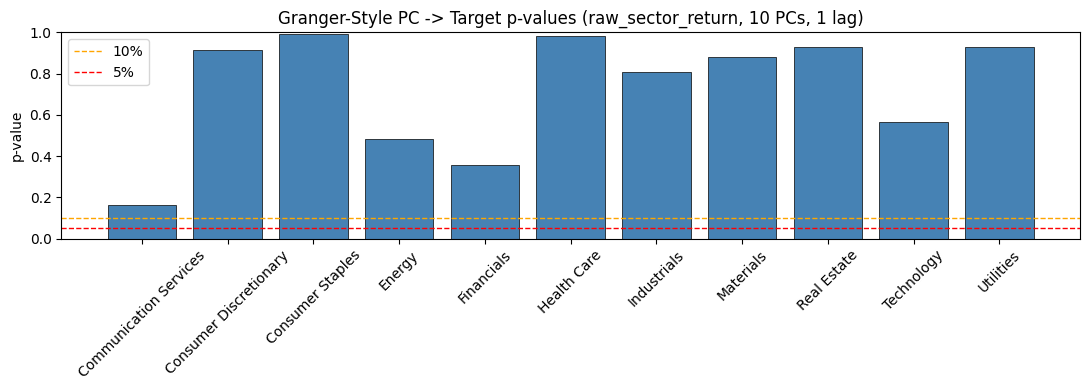

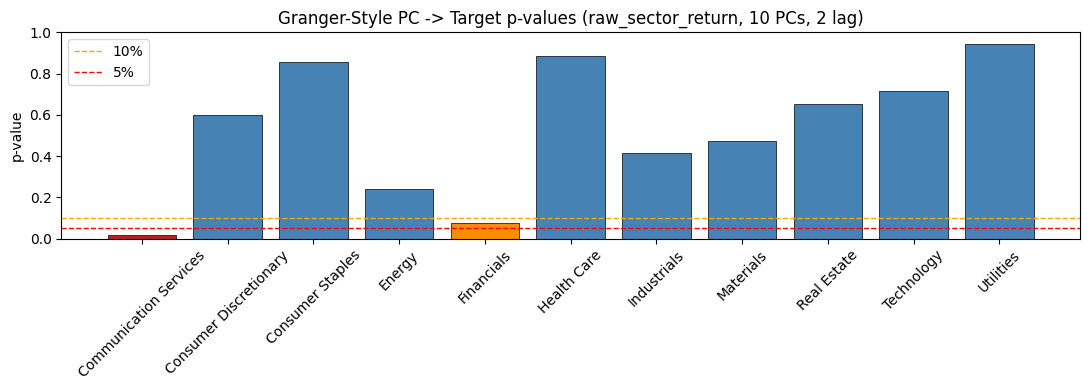

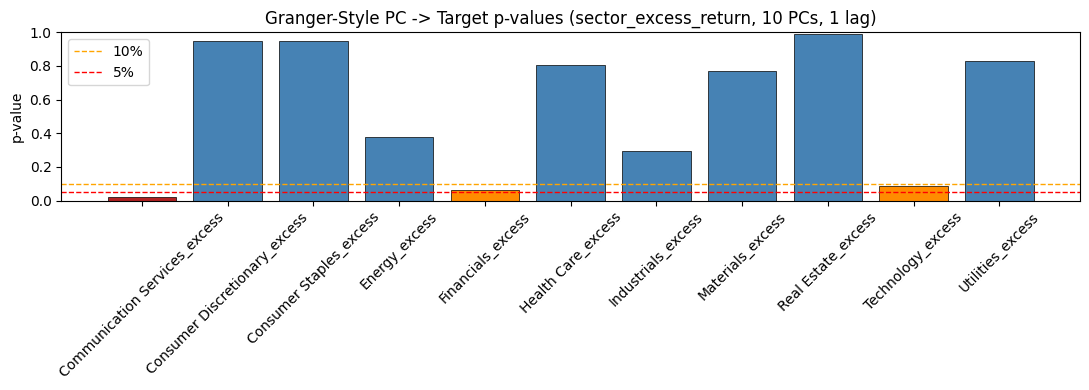

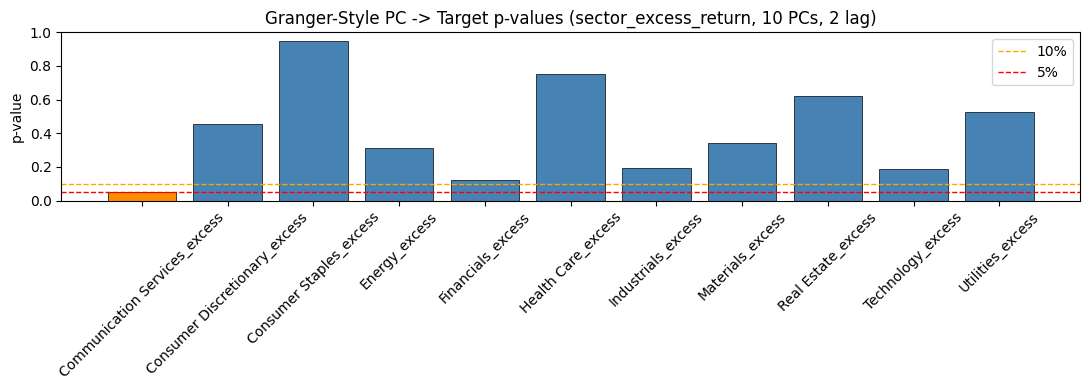

In [17]:
# Visualize p-values for the main 10-PC specification.
def plot_granger_pvalues(results, target_type, pc_count=10, lags=1):
    subset = results[
        (results["target_type"] == target_type)
        & (results["pc_count"] == pc_count)
        & (results["lags"] == lags)
    ].copy()
    subset = subset.sort_values("target")
    pvals = subset.set_index("target")["pvalue"]

    fig, ax = plt.subplots(figsize=(11, 4))
    colors = np.where(pvals < 0.05, "firebrick", np.where(pvals < 0.10, "darkorange", "steelblue"))
    ax.bar(pvals.index, pvals.values, color=colors, edgecolor="black", linewidth=0.5)
    ax.axhline(0.10, color="orange", linestyle="--", linewidth=1, label="10%")
    ax.axhline(0.05, color="red", linestyle="--", linewidth=1, label="5%")
    ax.set_title(f"Granger-Style PC -> Target p-values ({target_type}, {pc_count} PCs, {lags} lag)")
    ax.set_ylabel("p-value")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

for target_type in ["raw_sector_return", "sector_excess_return"]:
    for lag in GRANGER_LAGS:
        plot_granger_pvalues(pc_to_sector_granger, target_type, pc_count=10, lags=lag)


In [18]:
# Reverse direction: do sector returns Granger-predict individual PCs?
# Use complete-history sectors to avoid XLC-driven missing values in the sector block.
complete_sector_block = sector_returns_aligned[full_sample_sectors]

reverse_rows = []
for lags in GRANGER_LAGS:
    for pc in PC_DIAGNOSTIC_COLS:
        result = granger_block_test(pca_scores_aligned[pc], complete_sector_block, lags=lags)
        reverse_rows.append({
            "direction": "complete sectors -> PC",
            "target": pc,
            "lags": lags,
            **result,
        })

sector_to_pc_granger = pd.DataFrame(reverse_rows)
print("Smallest p-values for complete-sector block -> PC tests:")
sector_to_pc_granger.sort_values("pvalue").head(15)


Smallest p-values for complete-sector block -> PC tests:


,direction,target,lags,F,pvalue,nobs,df_num,df_den
18,complete sectors -> PC,PC6,2,2.149493,0.007347,118,20,95
24,complete sectors -> PC,PC12,2,1.684647,0.049497,118,20,95
12,complete sectors -> PC,PC13,1,1.795624,0.069921,119,10,107
25,complete sectors -> PC,PC13,2,1.499285,0.099615,118,20,95
19,complete sectors -> PC,PC7,2,1.322651,0.184275,118,20,95
15,complete sectors -> PC,PC3,2,1.291684,0.203953,118,20,95
5,complete sectors -> PC,PC6,1,1.356627,0.210502,119,10,107
14,complete sectors -> PC,PC2,2,1.241367,0.239396,118,20,95
6,complete sectors -> PC,PC7,1,1.295912,0.242041,119,10,107
9,complete sectors -> PC,PC10,1,1.098863,0.369754,119,10,107


In [19]:
# SPY direction checks: PCs -> SPY and SPY -> PCs.
spy_direction_rows = []
for pc_count in GRANGER_PC_COUNTS:
    pc_cols = [f"PC{i}" for i in range(1, pc_count + 1)]
    for lags in GRANGER_LAGS:
        result = granger_block_test(spy_returns_aligned["SPY"], pca_scores_aligned[pc_cols], lags=lags)
        spy_direction_rows.append({
            "direction": "PCs -> SPY",
            "target": "SPY",
            "pc_count": pc_count,
            "lags": lags,
            **result,
        })

for lags in GRANGER_LAGS:
    for pc in PC_DIAGNOSTIC_COLS:
        result = granger_block_test(pca_scores_aligned[pc], spy_returns_aligned[["SPY"]], lags=lags)
        spy_direction_rows.append({
            "direction": "SPY -> PC",
            "target": pc,
            "pc_count": 1,
            "lags": lags,
            **result,
        })

spy_granger = pd.DataFrame(spy_direction_rows)
spy_granger.sort_values("pvalue").head(20)


,direction,target,pc_count,lags,F,pvalue,nobs,df_num,df_den
24,SPY -> PC,PC6,1,2,5.347020,0.006043,118,2,113
21,SPY -> PC,PC3,1,2,4.222653,0.017038,118,2,113
11,SPY -> PC,PC6,1,1,3.537963,0.062486,119,1,116
20,SPY -> PC,PC2,1,2,2.247107,0.110408,118,2,113
10,SPY -> PC,PC5,1,1,2.304609,0.131711,119,1,116
19,SPY -> PC,PC1,1,2,1.822563,0.166330,118,2,113
13,SPY -> PC,PC8,1,1,1.794006,0.183057,119,1,116
25,SPY -> PC,PC7,1,2,1.683612,0.190326,118,2,113
8,SPY -> PC,PC3,1,1,1.456412,0.229957,119,1,116
23,SPY -> PC,PC5,1,2,1.227532,0.296892,118,2,113


In [20]:
# Save Granger-style diagnostic results.
pc_to_sector_granger.to_csv(DATA_DIR / "granger_pc_to_sector_results.csv", index=False)
sector_to_pc_granger.to_csv(DATA_DIR / "granger_sector_to_pc_results.csv", index=False)
spy_granger.to_csv(DATA_DIR / "granger_spy_direction_results.csv", index=False)

print("Saved Granger-style diagnostic files:")
print("  granger_pc_to_sector_results.csv")
print("  granger_sector_to_pc_results.csv")
print("  granger_spy_direction_results.csv")


Saved Granger-style diagnostic files:
  granger_pc_to_sector_results.csv
  granger_sector_to_pc_results.csv
  granger_spy_direction_results.csv


### Granger P-Value Heatmaps

Heatmaps summarize the Granger-style p-values by sector for the main 10-PC specification. Blue cells indicate lower p-values / stronger predictive evidence. Stars denote conventional significance levels.


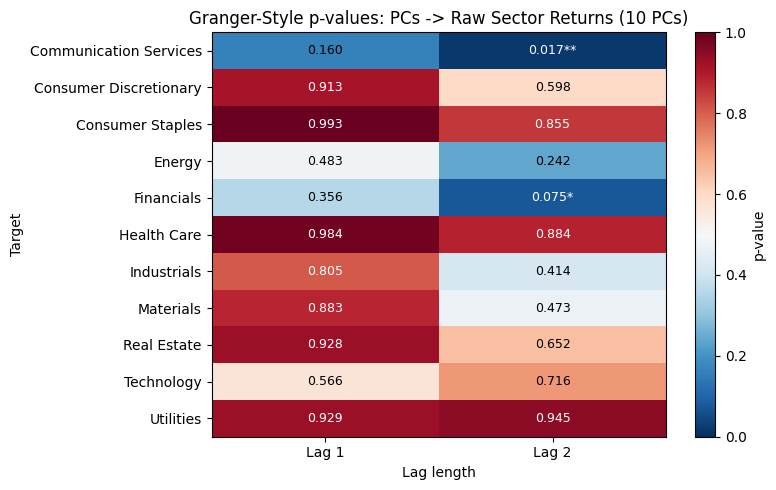

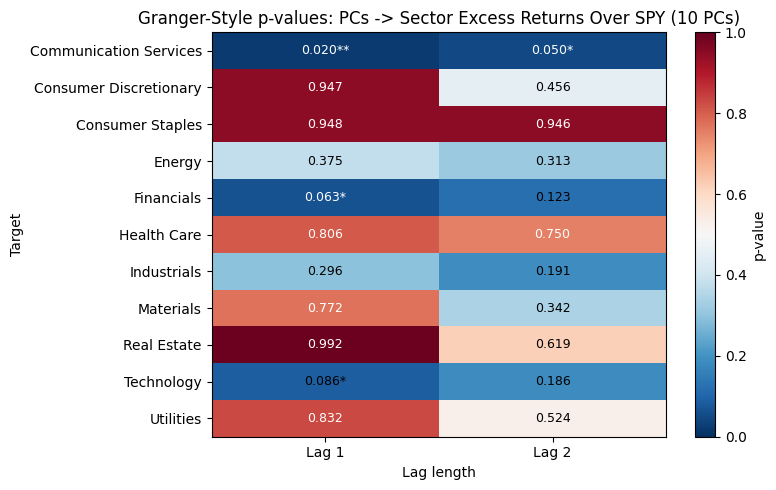

In [21]:
def _pvalue_label(p):
    if pd.isna(p):
        return ""
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
    return f"{p:.3f}{stars}"


def plot_granger_pvalue_heatmap(results, target_type, pc_count=10, title=None):
    subset = results[
        (results["target_type"] == target_type)
        & (results["pc_count"] == pc_count)
    ].copy()

    heat = subset.pivot(index="target", columns="lags", values="pvalue")
    heat = heat.reindex(columns=sorted(heat.columns))

    # For excess-return labels, strip the suffix so raw/excess heatmaps align visually.
    display_index = [idx.replace("_excess", "") for idx in heat.index]

    fig, ax = plt.subplots(figsize=(8, max(5, 0.42 * len(heat))))
    im = ax.imshow(heat.values.astype(float), cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([f"Lag {lag}" for lag in heat.columns])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(display_index)
    ax.set_title(title or f"Granger p-values: PCs -> {target_type} ({pc_count} PCs)")
    ax.set_xlabel("Lag length")
    ax.set_ylabel("Target")

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            p = heat.iloc[i, j]
            text_color = "white" if (pd.notna(p) and (p < 0.08 or p > 0.75)) else "black"
            ax.text(j, i, _pvalue_label(p), ha="center", va="center", fontsize=9, color=text_color)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("p-value")
    plt.tight_layout()
    plt.show()

    return heat

raw_granger_heatmap_10pc = plot_granger_pvalue_heatmap(
    pc_to_sector_granger,
    target_type="raw_sector_return",
    pc_count=10,
    title="Granger-Style p-values: PCs -> Raw Sector Returns (10 PCs)",
)

excess_granger_heatmap_10pc = plot_granger_pvalue_heatmap(
    pc_to_sector_granger,
    target_type="sector_excess_return",
    pc_count=10,
    title="Granger-Style p-values: PCs -> Sector Excess Returns Over SPY (10 PCs)",
)


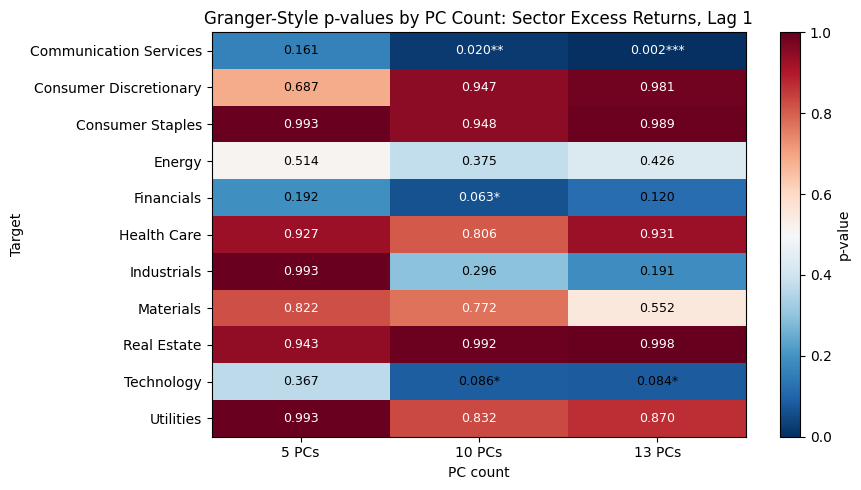

In [22]:
# Optional companion: compare the 5/10/13 PC specifications at lag 1 for excess returns.
def plot_pc_count_comparison_heatmap(results, target_type, lag=1, title=None):
    subset = results[
        (results["target_type"] == target_type)
        & (results["lags"] == lag)
    ].copy()
    heat = subset.pivot(index="target", columns="pc_count", values="pvalue")
    heat = heat.reindex(columns=GRANGER_PC_COUNTS)
    display_index = [idx.replace("_excess", "") for idx in heat.index]

    fig, ax = plt.subplots(figsize=(9, max(5, 0.42 * len(heat))))
    im = ax.imshow(heat.values.astype(float), cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([f"{n} PCs" for n in heat.columns])
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(display_index)
    ax.set_title(title or f"Granger p-values by PC count ({target_type}, lag {lag})")
    ax.set_xlabel("PC count")
    ax.set_ylabel("Target")

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            p = heat.iloc[i, j]
            text_color = "white" if (pd.notna(p) and (p < 0.08 or p > 0.75)) else "black"
            ax.text(j, i, _pvalue_label(p), ha="center", va="center", fontsize=9, color=text_color)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("p-value")
    plt.tight_layout()
    plt.show()
    return heat

excess_pc_count_lag1_heatmap = plot_pc_count_comparison_heatmap(
    pc_to_sector_granger,
    target_type="sector_excess_return",
    lag=1,
    title="Granger-Style p-values by PC Count: Sector Excess Returns, Lag 1",
)


### Directional Search-Return Causality Visuals

These figures are designed to answer the direction question more directly: do Google-search attention factors lead sector returns, or do sector/market returns lead search attention? Blue means lower p-values / stronger Granger-style evidence. For the reverse direction, each sector is tested against individual PCs and the heatmap reports the strongest sector -> PC relationship among the first 10 PCs, with the PC label shown in the cell.


In [23]:
# Build sector-by-sector directional p-value summaries.
DIRECTIONAL_PC_COUNT = 10
DIRECTIONAL_PC_COLS = [f"PC{i}" for i in range(1, DIRECTIONAL_PC_COUNT + 1)]
DIRECTIONAL_LAGS = [1, 2]


def strongest_target_to_pc(target_series, target_name, target_type, lags):
    rows = []
    for pc in DIRECTIONAL_PC_COLS:
        result = granger_block_test(pca_scores_aligned[pc], target_series.to_frame(target_name), lags=lags)
        rows.append({
            "target_type": target_type,
            "target": target_name,
            "pc": pc,
            "lags": lags,
            **result,
        })
    df = pd.DataFrame(rows).sort_values("pvalue")
    return df.iloc[0].to_dict()

reverse_sector_pc_rows = []
for lags in DIRECTIONAL_LAGS:
    for sector in sector_returns_aligned.columns:
        reverse_sector_pc_rows.append(
            strongest_target_to_pc(sector_returns_aligned[sector], sector, "raw_sector_return", lags)
        )
    for sector_excess in sector_excess_aligned.columns:
        reverse_sector_pc_rows.append(
            strongest_target_to_pc(sector_excess_aligned[sector_excess], sector_excess, "sector_excess_return", lags)
        )

reverse_sector_to_pc_best = pd.DataFrame(reverse_sector_pc_rows)
reverse_sector_to_pc_best.head()


,target_type,target,pc,lags,F,pvalue,nobs,df_num,df_den
0,raw_sector_return,Materials,PC7,1,1.876494,0.173379,119,1,116
1,raw_sector_return,Communication Services,PC6,1,4.389279,0.038944,94,1,91
2,raw_sector_return,Energy,PC8,1,1.067723,0.303610,119,1,116
3,raw_sector_return,Financials,PC6,1,2.782307,0.098008,119,1,116
4,raw_sector_return,Industrials,PC8,1,2.246959,0.136594,119,1,116


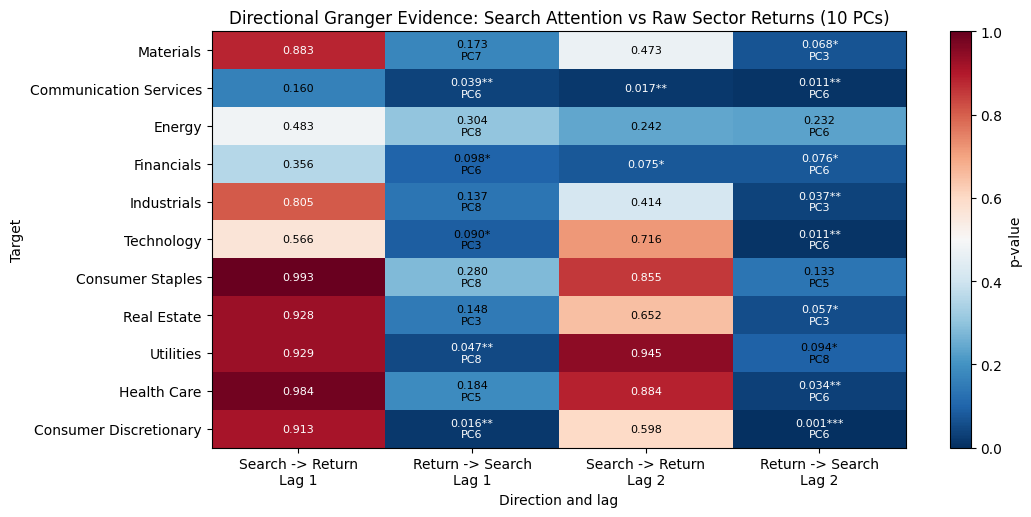

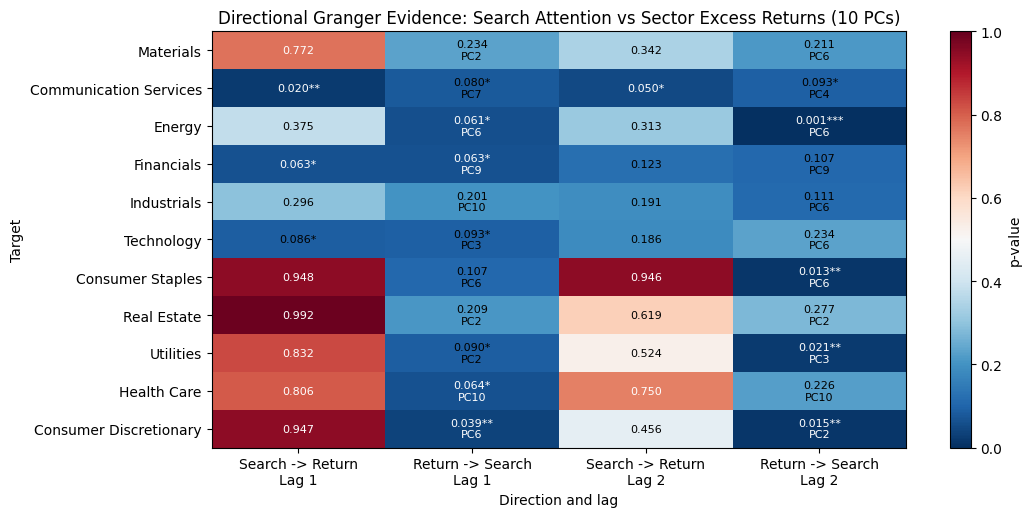

In [24]:
def _directional_label(p, pc=None):
    if pd.isna(p):
        return ""
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
    if pc is None:
        return f"{p:.3f}{stars}"
    return f"{p:.3f}{stars}\n{pc}"


def directional_causality_heatmap(target_type, pc_count=10, title=None):
    forward = pc_to_sector_granger[
        (pc_to_sector_granger["target_type"] == target_type)
        & (pc_to_sector_granger["pc_count"] == pc_count)
        & (pc_to_sector_granger["lags"].isin(DIRECTIONAL_LAGS))
    ].copy()
    reverse = reverse_sector_to_pc_best[
        (reverse_sector_to_pc_best["target_type"] == target_type)
        & (reverse_sector_to_pc_best["lags"].isin(DIRECTIONAL_LAGS))
    ].copy()

    targets = forward["target"].tolist()
    targets = list(dict.fromkeys(targets))
    display_targets = [target.replace("_excess", "") for target in targets]

    columns = []
    values = []
    labels = []
    for lag in DIRECTIONAL_LAGS:
        columns.append(f"Search -> Return\nLag {lag}")
        fwd = forward[forward["lags"] == lag].set_index("target").reindex(targets)
        values.append(fwd["pvalue"].to_numpy())
        labels.append([_directional_label(p) for p in fwd["pvalue"]])

        columns.append(f"Return -> Search\nLag {lag}")
        rev = reverse[reverse["lags"] == lag].set_index("target").reindex(targets)
        values.append(rev["pvalue"].to_numpy())
        labels.append([_directional_label(p, pc) for p, pc in zip(rev["pvalue"], rev["pc"])])

    heat = np.column_stack(values)
    label_arr = np.array(labels).T

    fig, ax = plt.subplots(figsize=(11, max(5, 0.48 * len(targets))))
    im = ax.imshow(heat.astype(float), cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(range(len(columns)))
    ax.set_xticklabels(columns)
    ax.set_yticks(range(len(targets)))
    ax.set_yticklabels(display_targets)
    ax.set_title(title or f"Directional Granger-Style p-values ({target_type}, {pc_count} PCs)")
    ax.set_xlabel("Direction and lag")
    ax.set_ylabel("Target")

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            p = heat[i, j]
            text_color = "white" if pd.notna(p) and (p < 0.08 or p > 0.75) else "black"
            ax.text(j, i, label_arr[i, j], ha="center", va="center", fontsize=8, color=text_color)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("p-value")
    plt.tight_layout()
    plt.show()

    out = pd.DataFrame(heat, index=targets, columns=columns)
    return out

raw_directional_heatmap = directional_causality_heatmap(
    "raw_sector_return",
    pc_count=10,
    title="Directional Granger Evidence: Search Attention vs Raw Sector Returns (10 PCs)",
)

excess_directional_heatmap = directional_causality_heatmap(
    "sector_excess_return",
    pc_count=10,
    title="Directional Granger Evidence: Search Attention vs Sector Excess Returns (10 PCs)",
)


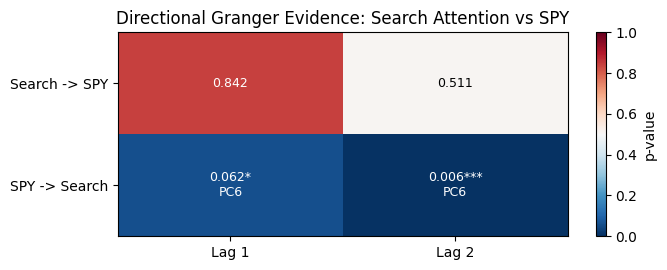

,direction,lags,pc,F,pvalue,nobs,df_num,df_den,target_type,target
0,Search -> SPY,1,None,0.561709,0.841666,119,10,107,NaN,NaN
1,SPY -> Search,1,PC6,3.537963,0.062486,119,1,116,market_return,SPY
2,Search -> SPY,2,None,0.964170,0.511146,118,20,95,NaN,NaN
3,SPY -> Search,2,PC6,5.347020,0.006043,118,2,113,market_return,SPY


In [25]:
# SPY directional companion: does broad market movement lead searches, or do searches lead SPY?
spy_rows = []
for lag in DIRECTIONAL_LAGS:
    fwd = granger_block_test(spy_returns_aligned["SPY"], pca_scores_aligned[DIRECTIONAL_PC_COLS], lags=lag)
    spy_rows.append({"direction": "Search -> SPY", "lags": lag, "pc": None, **fwd})

    best_reverse = strongest_target_to_pc(spy_returns_aligned["SPY"], "SPY", "market_return", lag)
    spy_rows.append({"direction": "SPY -> Search", **best_reverse})

spy_directional_summary = pd.DataFrame(spy_rows)

fig, ax = plt.subplots(figsize=(7, 2.8))
heat = spy_directional_summary.pivot(index="direction", columns="lags", values="pvalue")
label_pcs = spy_directional_summary.pivot(index="direction", columns="lags", values="pc")
heat = heat.reindex(["Search -> SPY", "SPY -> Search"])
label_pcs = label_pcs.reindex(heat.index)

im = ax.imshow(heat.values.astype(float), cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels([f"Lag {lag}" for lag in heat.columns])
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title("Directional Granger Evidence: Search Attention vs SPY")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        p = heat.iloc[i, j]
        pc = label_pcs.iloc[i, j]
        label = _directional_label(p, None if pd.isna(pc) else pc)
        text_color = "white" if pd.notna(p) and (p < 0.08 or p > 0.75) else "black"
        ax.text(j, i, label, ha="center", va="center", fontsize=9, color=text_color)

plt.colorbar(im, ax=ax, label="p-value")
plt.tight_layout()
plt.show()

spy_directional_summary


In [26]:
# Save directional summaries.
reverse_sector_to_pc_best.to_csv(DATA_DIR / "granger_sector_to_pc_best_by_sector.csv", index=False)
raw_directional_heatmap.to_csv(DATA_DIR / "granger_directional_raw_heatmap.csv")
excess_directional_heatmap.to_csv(DATA_DIR / "granger_directional_excess_heatmap.csv")
spy_directional_summary.to_csv(DATA_DIR / "granger_directional_spy_summary.csv", index=False)

print("Saved directional Granger summary files:")
print("  granger_sector_to_pc_best_by_sector.csv")
print("  granger_directional_raw_heatmap.csv")
print("  granger_directional_excess_heatmap.csv")
print("  granger_directional_spy_summary.csv")


Saved directional Granger summary files:
  granger_sector_to_pc_best_by_sector.csv
  granger_directional_raw_heatmap.csv
  granger_directional_excess_heatmap.csv
  granger_directional_spy_summary.csv
